In [1]:
%%time
%matplotlib inline
import rioxarray
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import importlib 
import matplotlib.pyplot as plt

CPU times: total: 4.53 s
Wall time: 21.6 s


In [2]:
vv = rioxarray.open_rasterio('../input/STVV_202223.tif')
vh = rioxarray.open_rasterio('../input/STVH_202223.tif')
ndvi = rioxarray.open_rasterio('../input/STNDVI_202223.tif')


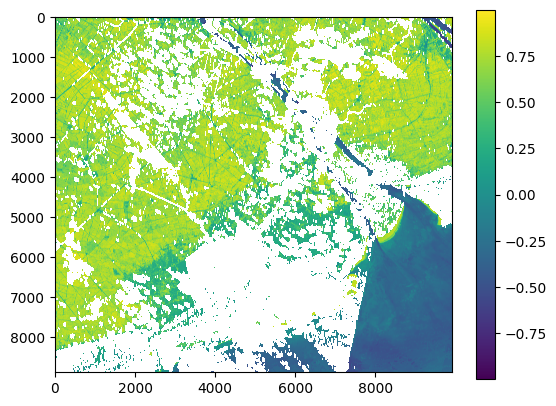

In [3]:
plt.imshow(ndvi[5], cmap='viridis')  # Display Band 10
plt.colorbar()  # Show the scale
plt.show()

In [4]:
ndvi

<xarray.DataArray (band: 13, y: 8874, x: 9902)> Size: 5GB
[1142314524 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      NDVI

In [3]:
import geopandas as gpd
train_path = "../input/STtrain1130v2.shp"  
# train_path = "train/updated_data/ThuanHoa_DKS_Kappa.shp"
ground_points = gpd.read_file(train_path)
ground_points.shape

(1130, 7)

In [4]:
ground_points

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1,603860.819,1081162.862,Pomelo,CLN,3,POINT (603860.819 1081162.862)
1,2,601306.410,1082782.940,Pomelo,CLN,3,POINT (601306.41 1082782.94)
2,3,601084.510,1081351.870,Pomelo,CLN,3,POINT (601084.51 1081351.87)
3,4,602193.760,1079205.220,Pomelo,CLN,3,POINT (602193.76 1079205.22)
4,5,602459.000,1080946.000,Pomelo,CLN,3,POINT (602459 1080946)
...,...,...,...,...,...,...,...
1125,1126,NaN,NaN,None,Lua,1,POINT (615037.942 1073775.571)
1126,1127,NaN,NaN,None,Lua,1,POINT (607251.06 1074193.443)
1127,1128,NaN,NaN,None,Lua,1,POINT (610268.577 1076995.997)
1128,1129,NaN,NaN,None,Lua,1,POINT (602419.417 1058229.934)


In [4]:
def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [5]:
full_data = extract_data_with_HTcode(ground_points, ndvi, vh, vv)

In [104]:
ht_code = 2
lua2_ndvi = full_data[ht_code]['ndvi']
lua2_vh = full_data[ht_code]['vh']
lua2_ndvi

[array([       nan,        nan,        nan, 0.59529704, 0.69562805,
        0.46187472, 0.64586496, 0.665983  , 0.48141885,        nan,
               nan, 0.44437903, 0.54915   ], dtype=float32),
 array([       nan,        nan,        nan, 0.41753826, 0.39387226,
               nan, 0.69331837, 0.3544887 , 0.55816746,        nan,
               nan, 0.4057352 , 0.34712347], dtype=float32),
 array([       nan,        nan,        nan, 0.29395014, 0.65954775,
               nan, 0.69776845, 0.24574554,        nan, 0.14196429,
               nan, 0.6533487 ,        nan], dtype=float32),
 array([       nan,        nan,        nan, 0.1207547 , 0.2498627 ,
               nan, 0.18692732, 0.06837961,        nan,        nan,
               nan, 0.20125625,        nan], dtype=float32),
 array([       nan,        nan,        nan, 0.46215385, 0.5570825 ,
               nan, 0.39600468, 0.31260657, 0.3685333 ,        nan,
               nan, 0.4735368 , 0.7352402 ], dtype=float32),
 array([       

In [32]:
len(lua2_vh)
# lua2_vh[0].shape[0]

55

In [109]:
import importlib
import fourierParam as params
# Reload module
importlib.reload(params)
months = np.arange(13)
scales = params.chn_scale 
bias = params.chn_bias
bias

0.579999999999881

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
# bias =  0.6699999999998791
# scale_factor = 0.15279367314245765
# Tạo mảng lưu NDVI nội suy
ndvi_preds = []
for i, vh in enumerate(lua2_vh):
    
    fft_vh = fft(vh)
    intercep = fft_vh*scales
    res = np.real(ifft(intercep)) + bias
    ndvi_preds.append(res)

In [96]:
ndvi_preds

[array([ 0.69791727, -0.42366517,  0.84475689,  0.97592503,  1.21603424,
         1.19523926,  0.36921369,  0.27641907,  0.51198603, -0.01113956,
         0.31027001,  0.9592763 ,  1.27408195]),
 array([0.80430123, 0.20900356, 0.67337099, 0.93430277, 0.61581662,
        0.28810497, 0.40571049, 0.78246398, 0.85162015, 0.73640574,
        0.76271772, 0.97928138, 0.73541859]),
 array([ 0.98564391, -0.61410582, -0.43149887,  0.785699  ,  1.15468856,
         1.70835937,  0.98720075,  0.53278088,  0.47772291, -0.3212978 ,
         0.56263938,  1.06169927,  1.02473522]),
 array([ 1.040441  , -0.17301388,  0.48099008,  1.20382371,  0.90392955,
         0.01292329,  0.24389808,  1.00831158,  0.74169214,  0.32214605,
         1.07607668,  0.87914975,  0.791963  ]),
 array([ 0.98516187,  0.57652503, -0.69461213, -0.62974739,  0.52060025,
         0.7312175 ,  0.96135577,  0.60461523,  0.61424103,  1.36117075,
         0.93812501,  1.11611028,  1.25216308]),
 array([-0.07146572,  0.52025486,  1.1

In [26]:
# def normalize_to_minus1_1(array):
#     min_val = np.min(array)
#     max_val = np.max(array)
#     if max_val == min_val:  # Tránh chia cho 0
#         return np.zeros_like(array)
#     normalized = -1 + 2 * (array - min_val) / (max_val - min_val)
#     return normalized

# # Áp dụng chuẩn hóa cho từng mảng
# normalized_data = normalize_to_minus1_1(ndvi_preds)

# # In kết quả
# print(normalized_data)

In [10]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

def draw_ndvi(actual_values, predicted_values, name):
    for i, data in enumerate(actual_values):
        plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
    for i, data in enumerate(predicted_values):
        plt.plot(months, data, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75, label='predicted Values (o)' if i == 0 else "")
    plt.xlabel('Months')
    plt.ylabel('NDVI values')
    plt.title(f'Comparison: Actual vs Predicted Values in {name} code over 13 months')
    # Adding grid
    plt.grid(True)
    plt.legend(loc='best')
    # Adding legend to differentiate the lines
    plt.legend()
    # Adjusting the limits of the axes
    # plt.xlim(0, max(len(arr) for arr in actual_values))  # Adjust x-axis limits based on the longest array
    # plt.ylim(-1, 1)  # Example: Setting y-axis limits
    # Display the plot
    plt.show()

    


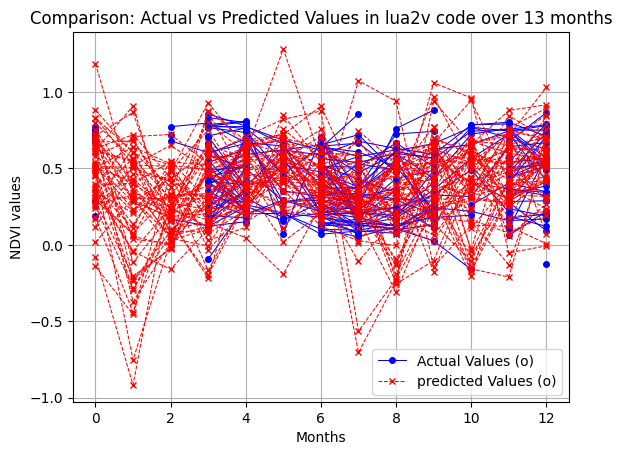

In [111]:
draw_ndvi(lua2_ndvi, ndvi_preds, "lua2v")


In [101]:
import numpy as np
alpha = 0.3
def custom_clip_ndvi(ndvi_list):
    ndvi_clipped = []
    for ndvi in ndvi_list:
        ndvi_corrected = ndvi.copy()
        print(f"before: {ndvi_corrected}")
        # Giá trị vượt trên 1 → log nén
        mask_high = ndvi_corrected > 1
        ndvi_corrected[mask_high] = 1 + alpha * np.log10(ndvi_corrected[mask_high] - 1 + 1e-6)
        print(f"after 1: {ndvi_corrected}")
        # Giá trị nhỏ hơn -1 → log nén đối xứng
        mask_low = ndvi_corrected < -1
        ndvi_corrected[mask_low] = -1 - alpha * np.log10(-ndvi_corrected[mask_low] - 1 + 1e-6)
        print(f"after 2: {ndvi_corrected}")
        ndvi_clipped.append(ndvi_corrected)
    
    return ndvi_clipped



In [37]:
def normalize(data):
    data_min = np.nanmin(data)
    data_max = np.nanmax(data)
    
    # Áp dụng công thức chuẩn hóa
    normalized = 2 * (data - data_min) / (data_max - data_min) - 1
    
    # Giữ nguyên giá trị NaN
    normalized = np.where(np.isnan(data), np.nan, normalized)
    return normalized

In [ ]:
# alpha = 0.3
# def custom_clip_ndvi_array(ndvi_array):
#     ndvi_corrected = ndvi_array.copy()
#     mask_high = ndvi_corrected > 1
#     mask_low = ndvi_corrected < -1
    
#     ndvi_corrected[mask_high] = 1 + alpha + np.log10(ndvi_corrected[mask_high] - 1 + 1e-6)
#     ndvi_corrected[mask_low] = -1 - alpha + np.log10(-ndvi_corrected[mask_low] - 1 + 1e-6)
    
#     return ndvi_corrected


In [112]:
nor = custom_clip_ndvi(ndvi_preds)


before: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
after 1: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
after 2: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
before: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  0.54376298]
after 1: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  0.54376298]
after 2: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  

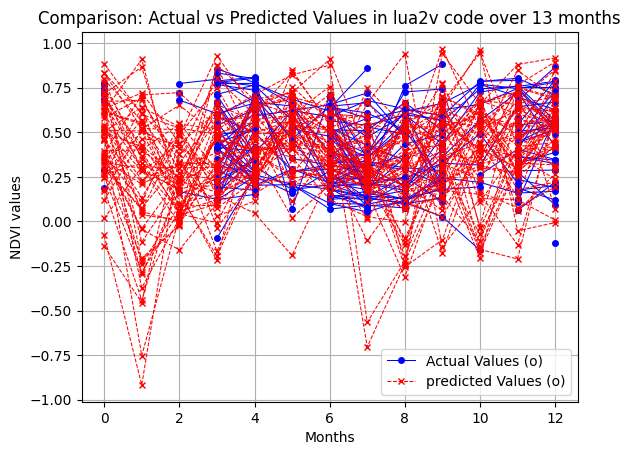

In [113]:
draw_ndvi(lua2_ndvi, nor, "lua2v")

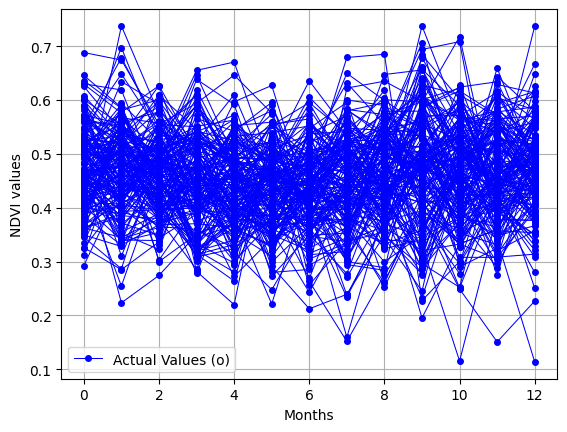

In [14]:

for i, data in enumerate(ndvi_preds):
    plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
plt.xlabel('Months')
plt.ylabel('NDVI values')
# Adding grid
plt.grid(True)
plt.legend(loc='best')

# Display the plot
plt.show()

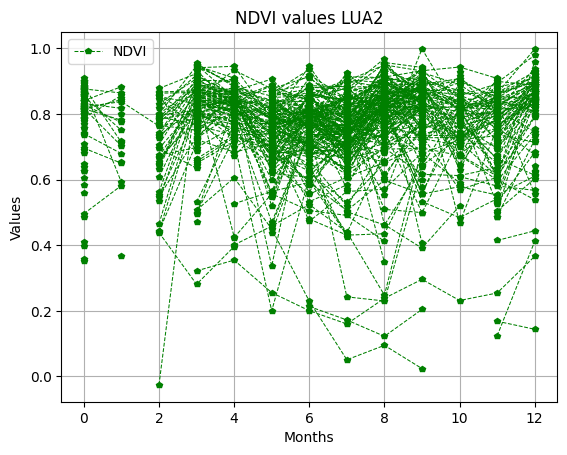

In [15]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='NDVI' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'NDVI values LUA2')

draw_vh(lua2_ndvi)

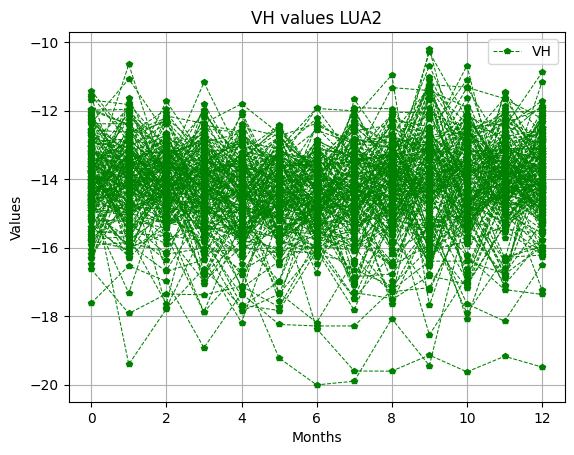

In [16]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='VH' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'VH values LUA2')

draw_vh(lua2_vh)

In [ ]:
import numpy as np
import xarray as xr

ndvi_band = ndvi[5]
vh_band = vh[5]

# Tạo bản sao để không ghi đè dữ liệu gốc
ndvi_filled = ndvi_band.copy()

# Tìm vị trí bị NaN
mask_nan = np.isnan(ndvi_band)

# Gán giá trị mới vào chỗ NaN dựa trên VH
ndvi_filled.values[mask_nan.values] = estimate_ndvi_from_vh(vh_band.values[mask_nan.values])
